## Goal Locations for the League's Top 5 Goal Scorers

##### 1.Leon Draisaitl - 52 
##### 2.William Nylander - 45
##### T-3.Alex Ovechkin - 44
##### T-3. Tage Thompson - 44
##### 5. David Pastrnak - 43

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
from matplotlib import image 
from matplotlib import pyplot as plt 

In [2]:
#import the data
#index col = [0] makes sures another index column is not added
goal_data = pd.read_csv(r'C:\Users\Alex\Documents\NHL-Stats\2024-2025\SQL\Query-Results\goals_top_5_scorers_cut.csv', index_col = [0])

In [3]:
#add a column which indicates whether the goal occured for the home team (1=home team, 0=away team)
goal_data['home_team'] = np.where(goal_data['h_team_id'] == goal_data['event_owner_team_id'], 1, 0)

In [5]:
#create a list of conditions 
conditions = [
    (goal_data['home_team'] == 1),
    (goal_data['home_team'] == 0) & (goal_data['home_def_code'] == 'right'),
    (goal_data['home_team'] == 0) & (goal_data['home_def_code'] == 'left')
]

#create a list of values to assign to each condition 
values = [goal_data['home_def_code'], 'left', 'right']

#create a new column for the rinkside info 
goal_data['rinkside'] = np.select(conditions, values)

In [11]:
goal_data.head()

,h_team_id,a_team_id,game_period,time_remaining,home_def_code,event_owner_team_id,x_coord,y_coord,shot_type,score_player_id,home_team,rinkside,x_coord_2,y_coord_2
game_id,,,,,,,,,,,,,,
2024020002,1,7,2,11:42,right,7,84,-5,poke,8479420,0,left,-84,5
2024020004,13,6,3,1:45,right,6,79,25,wrist,8477956,0,left,-79,-25
2024020011,6,8,2,4:04,right,6,-62,5,slap,8477956,1,right,-62,5
2024020024,6,26,4,1:53,right,6,-80,8,wrist,8477956,1,right,-80,8
2024020025,7,13,1,2:33,left,7,62,-22,wrist,8479420,1,left,-62,22


In [8]:
#set the inverse multiplier
inverse = -1

In [9]:
#prepping the data - need all shots to be going in the same direction - right side 
#x_coordinate
goal_data['x_coord_2'] = np.where(goal_data['rinkside'] == 'left',              #condition 
                                                goal_data['x_coord'] * inverse, #what to assign when condition is true
                                                goal_data['x_coord']            #what to assign when the conditon is false 
                                            )

In [10]:
#prepping the data - need all shots to be going in the same direction - right side 
#y_coordinate
goal_data['y_coord_2'] = np.where(goal_data['rinkside'] == 'left',              #condition 
                                                goal_data['y_coord'] * inverse, #what to assign when condition is true
                                                goal_data['y_coord']            #what to assign when the conditon is false 
                                            )

## Plotting all goals 

<Axes: xlabel='x_coord', ylabel='y_coord'>

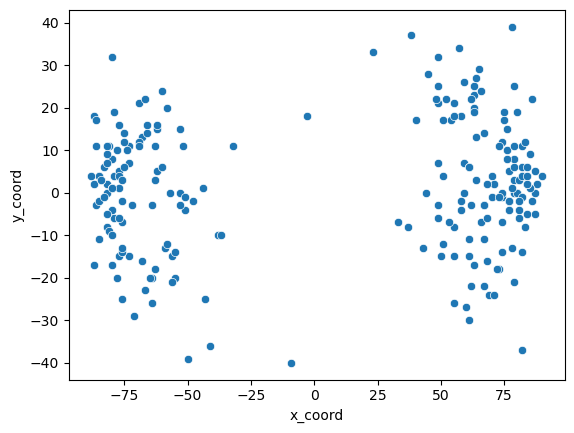

In [12]:
#plotting coordinates on scatterplot - before inversing so shots are all shown on one side of the rink 
sns.scatterplot(data = goal_data, x = 'x_coord', y = 'y_coord')

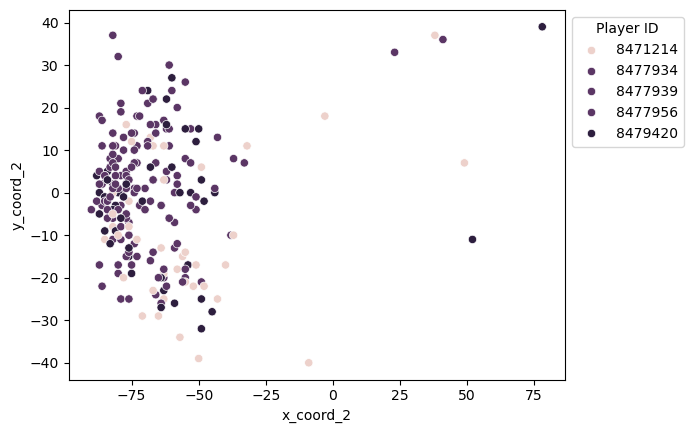

In [16]:
#plotting coordinates on scatterplot - after inverting so shots are on the same side of the rink - shows all goals from top 5 scorers 
sns.scatterplot(data = goal_data, x = 'x_coord_2', y = 'y_coord_2', hue = 'score_player_id')
plt.legend(title='Player ID', loc='upper left', bbox_to_anchor=(1, 1))

## 1. Leon Draisaitl 

In [18]:
#creating dataframe with only data for Leon Draisaitl 
#Draisaitl's player id = 8477934

ld_data = goal_data[goal_data['score_player_id'] == 8477934]

In [31]:
#determine how many rows to make sure goal count correct
ld_data.shape

(52, 14)

In [26]:
ld_data.head(1)

,h_team_id,a_team_id,game_period,time_remaining,home_def_code,event_owner_team_id,x_coord,y_coord,shot_type,score_player_id,home_team,rinkside,x_coord_2,y_coord_2
game_id,,,,,,,,,,,,,,
2024020036,22,16,3,9:59,left,22,74,12,wrist,8477934,1,left,-74,-12


## 2. William Nylander 

In [43]:
#creating dataframe with only data for William Nylander 
#Nylander's player id = 8477939

wn_data = goal_data[goal_data['score_player_id'] == 8477939]

In [48]:
#after using df.shape - we have 47 goals for Nylander - from investigation P5 goals are showing 
#removing P5 goals 
#rows = wn_data[wn_data['game_period'] == 5].index
#wn_data.drop(rows, inplace=True)

In [49]:
wn_data.head()

,h_team_id,a_team_id,game_period,time_remaining,home_def_code,event_owner_team_id,x_coord,y_coord,shot_type,score_player_id,home_team,rinkside,x_coord_2,y_coord_2
game_id,,,,,,,,,,,,,,
2024020026,10,5,2,19:10,left,10,82,6,snap,8477939,1,left,-82,-6
2024020026,10,5,3,0:22,right,10,-81,11,snap,8477939,1,right,-81,11
2024020058,10,26,2,1:29,left,10,55,-26,wrist,8477939,1,left,-55,26
2024020091,10,14,1,16:03,right,10,-64,-3,snap,8477939,1,right,-64,-3
2024020091,10,14,2,12:27,left,10,73,-18,wrist,8477939,1,left,-73,18


## T-3. Alex Ovechkin

In [50]:
#creating a dataframe with only data for Alex Ovechkin
#Ovechkin's player id = 8471214

ao_data = goal_data[goal_data['score_player_id'] == 8471214]

In [52]:
ao_data.head()

,h_team_id,a_team_id,game_period,time_remaining,home_def_code,event_owner_team_id,x_coord,y_coord,shot_type,score_player_id,home_team,rinkside,x_coord_2,y_coord_2
game_id,,,,,,,,,,,,,,
2024020080,1,15,1,5:42,left,15,-77,4,tip-in,8471214,0,right,-77,4
2024020108,15,4,3,1:10,right,15,-50,-39,backhand,8471214,1,right,-50,-39
2024020151,15,3,1,16:37,right,15,-56,-15,wrist,8471214,1,right,-56,-15
2024020151,15,3,1,14:50,right,15,-79,-6,snap,8471214,1,right,-79,-6
2024020164,15,8,3,7:33,right,15,-85,-11,snap,8471214,1,right,-85,-11


## T-3. Tage Thompson 

In [58]:
#creating a dataframe with only data for Tage Thompson 
#Thompson's player id = 8479420

tt_data = goal_data[goal_data['score_player_id'] == 8479420]

In [61]:
tt_data.shape

(44, 14)

In [62]:
tt_data.head()

,h_team_id,a_team_id,game_period,time_remaining,home_def_code,event_owner_team_id,x_coord,y_coord,shot_type,score_player_id,home_team,rinkside,x_coord_2,y_coord_2
game_id,,,,,,,,,,,,,,
2024020002,1,7,2,11:42,right,7,84,-5,poke,8479420,0,left,-84,5
2024020025,7,13,1,2:33,left,7,62,-22,wrist,8479420,1,left,-62,22
2024020057,5,7,1,19:17,left,7,-88,4,wrap-around,8479420,0,right,-88,4
2024020085,16,7,1,11:21,right,7,44,0,wrist,8479420,0,left,-44,0
2024020095,7,25,3,15:43,left,7,54,17,slap,8479420,1,left,-54,-17


## 5. David Pastrnak

In [63]:
#creating a dataframe with only data for David Pastrnak 
#Pastrnak's player id = 8477956

dp_data = goal_data[goal_data['score_player_id'] == 8477956]

In [64]:
dp_data.shape

(43, 14)

In [65]:
dp_data.head()

,h_team_id,a_team_id,game_period,time_remaining,home_def_code,event_owner_team_id,x_coord,y_coord,shot_type,score_player_id,home_team,rinkside,x_coord_2,y_coord_2
game_id,,,,,,,,,,,,,,
2024020004,13,6,3,1:45,right,6,79,25,wrist,8477956,0,left,-79,-25
2024020011,6,8,2,4:04,right,6,-62,5,slap,8477956,1,right,-62,5
2024020024,6,26,4,1:53,right,6,-80,8,wrist,8477956,1,right,-80,8
2024020059,21,6,2,10:51,left,6,-83,6,wrist,8477956,0,right,-83,6
2024020109,6,25,1,8:03,left,6,70,-1,snap,8477956,1,left,-70,1
